**Секція 1. Логістична регресія з нуля.**

Будемо крок за кроком будувати модель лог регресії з нуля для передбачення, чи буде врожай більше за 80 яблук (задача подібна до лекційної, але на класифікацію).

Давайте нагадаємо основні формули для логістичної регресії.

### Функція гіпотези - обчислення передбачення у логістичній регресії:

$$
\hat{y} = \sigma(x W^T + b) = \frac{1}{1 + e^{-(x W^T + b)}}
$$

Де:
- $ \hat{y} $ — це ймовірність "позитивного" класу.
- $ x $ — це вектор (або матриця для набору прикладів) вхідних даних.
- $ W $ — це вектор (або матриця) вагових коефіцієнтів моделі.
- $ b $ — це зміщення (bias).
- $ \sigma(z) $ — це сигмоїдна функція активації.

### Як обчислюється сигмоїдна функція:

Сигмоїдна функція $ \sigma(z) $ має вигляд:

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

Ця функція перетворює будь-яке дійсне значення $ z $ в інтервал від 0 до 1, що дозволяє інтерпретувати вихід як ймовірність для логістичної регресії.

### Формула функції втрат для логістичної регресії (бінарна крос-ентропія):

Функція втрат крос-ентропії оцінює, наскільки добре модель передбачає класи, порівнюючи передбачені ймовірності $ \hat{y} $ із справжніми мітками $ y $. Формула наступна:

$$
L(y, \hat{y}) = - \left[ y \cdot \log(\hat{y}) + (1 - y) \cdot \log(1 - \hat{y}) \right]
$$

Де:
- $ y $ — це справжнє значення (мітка класу, 0 або 1).
- $ \hat{y} $ — це передбачене значення (ймовірність).



1.
Тут вже наведений код для ініціювання набору даних в форматі numpy. Перетворіть `inputs`, `targets` на `torch` тензори. Виведіть результат на екран.

In [ ]:
import torch
import numpy as np

In [ ]:
# Вхідні дані (temp, rainfall, humidity)
inputs = np.array([[73, 67, 43],
                   [91, 88, 64],
                   [87, 134, 58],
                   [102, 43, 37],
                   [69, 96, 70]], dtype='float32')

# Таргети (apples > 80)
targets = np.array([[0],
                    [1],
                    [1],
                    [0],
                    [1]], dtype='float32')

In [ ]:
# Перетворюємо numpy масиви на torch тензори
inputs_tensor = torch.from_numpy(inputs)
targets_tensor = torch.from_numpy(targets)

print("Inputs tensor:")
print(inputs_tensor)
print("\nTargets tensor:")
print(targets_tensor)

Inputs tensor:
tensor([[ 73.,  67.,  43.],
        [ 91.,  88.,  64.],
        [ 87., 134.,  58.],
        [102.,  43.,  37.],
        [ 69.,  96.,  70.]])

Targets tensor:
tensor([[0.],
        [1.],
        [1.],
        [0.],
        [1.]])


2. Ініціюйте ваги `w`, `b` для моделі логістичної регресії потрібної форми зважаючи на розмірності даних випадковими значеннями з нормального розподілу. Лишаю тут код для фіксації `random_seed`.

In [ ]:
torch.random.manual_seed(1)

In [ ]:
# Ініціалізація ваг: w має форму (1, 3) бо 3 ознаки і 1 вихід, b - (1,)
w = torch.randn(1, 3, requires_grad=True)
b = torch.randn(1, requires_grad=True)

print("w:", w)
print("b:", b)

w: tensor([[0.6614, 0.2669, 0.0617]], requires_grad=True)
b: tensor([0.6213], requires_grad=True)


3. Напишіть функцію `model`, яка буде обчислювати функцію гіпотези в логістичній регресії і дозволяти робити передбачення на основі введеного рядка даних і коефіцієнтів в змінних `w`, `b`.

  **Важливий момент**, що функція `model` робить обчислення на `torch.tensors`, тож для математичних обчислень використовуємо фукнціонал `torch`, наприклад:
  - обчсилення $e^x$: `torch.exp(x)`
  - обчсилення $log(x)$: `torch.log(x)`
  - обчислення середнього значення вектору `x`: `torch.mean(x)`

  Використайте функцію `model` для обчислення передбачень з поточними значеннями `w`, `b`.Виведіть результат обчислень на екран.

  Проаналізуйте передбачення. Чи не викликають вони у вас підозр? І якщо викликають, то чим це може бути зумовлено?

In [ ]:
def model(x, w, b):
    z = x @ w.t() + b
    return 1 / (1 + torch.exp(-z))

# Обчислення передбачень
preds = model(inputs_tensor, w, b)
print("Predictions:")
print(preds)

Predictions:
tensor([[1.],
        [1.],
        [1.],
        [1.],
        [1.]], grad_fn=<MulBackward0>)


Передбачення викликають підозри — всі значення рівні 1.0, хоча в таргетах є і нулі, і одиниці. Модель однаково впевнено відносить всі приклади до класу 1, що явно неправильно.

Це може бути зумовлено тим, що ваги w та b були ініціалізовані випадковими значеннями з нормального розподілу, які виявились занадто великими. Через це лінійна комбінація z = x @ w.T + b дає дуже великі значення, і сигмоїдна функція "насичується" — виходить у зону, де вона майже горизонтальна і повертає значення близькі до 1 для всіх входів.

---



4. Напишіть функцію `binary_cross_entropy`, яка приймає на вхід передбачення моделі `predicted_probs` та справжні мітки в даних `true_labels` і обчислює значення втрат (loss)  за формулою бінарної крос-ентропії для кожного екземпляра та вертає середні втрати по всьому набору даних.
  Використайте функцію `binary_cross_entropy` для обчислення втрат для поточних передбачень моделі.

In [ ]:
def binary_cross_entropy(predicted_probs, true_labels):
    loss = -(true_labels * torch.log(predicted_probs) + (1 - true_labels) * torch.log(1 - predicted_probs))
    return torch.mean(loss)

loss = binary_cross_entropy(preds, targets_tensor)
print("Loss:", loss)

Loss: tensor(nan, grad_fn=<MeanBackward0>)


5. Зробіть зворотнє поширення помилки і виведіть градієнти за параметрами `w`, `b`. Проаналізуйте їх значення. Як гадаєте, чому вони саме такі?

In [ ]:
loss.backward()

print("Градієнти w:", w.grad)
print("Градієнти b:", b.grad)

Градієнти w: tensor([[nan, nan, nan]])
Градієнти b: tensor([nan])


Градієнти рівні nan, що є наслідком двох проблем одночасно:

Через великі ваги сигмоїда насичується і повертає рівно 1.0 для всіх прикладів
У функції втрат для прикладів з міткою 0 обчислюється log(1 - 1.0) = log(0), що математично є невизначеним (-∞)
Через це loss = nan, і backpropagation не може обчислити градієнти — вони теж стають nan. Модель повністю "зламана" і навчання неможливе. Це ще наочніше показує, наскільки критична правильна ініціалізація ваг.

---



**Що сталось?**

В цій задачі, коли ми ініціювали значення випадковими значеннями з нормального розподілу, насправді ці значення не були дуже гарними стартовими значеннями і привели до того, що градієнти стали дуже малими або навіть рівними нулю (це призводить до того, що градієнти "зникають"), і відповідно при оновленні ваг у нас не буде нічого змінюватись. Це називається `gradient vanishing`. Це відбувається через **насичення сигмоїдної функції активації.**

У нашій задачі ми використовуємо сигмоїдну функцію активації, яка має такий вигляд:

   $$
   \sigma(z) = \frac{1}{1 + e^{-z}}
   $$


Коли значення $z$ дуже велике або дуже мале, сигмоїдна функція починає "насичуватись". Це означає, що для великих позитивних $z$ сигмоїда наближається до 1, а для великих негативних — до 0. В цих діапазонах градієнти починають стрімко зменшуватись і наближаються до нуля (бо градієнт - це похідна, похідна на проміжку функції, де вона паралельна осі ОХ, дорівнює 0), що робить оновлення ваг неможливим.

![](https://editor.analyticsvidhya.com/uploads/27889vaegp.png)

У логістичній регресії $ z = x \cdot w + b $. Якщо ваги $w, b$ - великі, значення $z$ також буде великим, і сигмоїда перейде в насичену область, де градієнти дуже малі.

Саме це сталося в нашій задачі, де великі випадкові значення ваг викликали насичення сигмоїдної функції. Це в свою чергу призводить до того, що під час зворотного поширення помилки (backpropagation) модель оновлює ваги дуже повільно або зовсім не оновлює. Це називається проблемою **зникнення градієнтів** (gradient vanishing problem).

**Що ж робити?**
Ініціювати ваги маленькими значеннями навколо нуля. Наприклад ми можемо просто в існуючій ініціалізації ваги розділити на 1000. Можна також використати інший спосіб ініціалізації вагів - інформація про це [тут](https://www.geeksforgeeks.org/initialize-weights-in-pytorch/).

Як це робити - показую нижче. **Виконайте код та знову обчисліть передбачення, лосс і виведіть градієнти.**

А я пишу пояснення, чому просто не зробити

```
w = torch.randn(1, 3, requires_grad=True)/1000
b = torch.randn(1, requires_grad=True)/1000
```

Нам потрібно, аби тензори вагів були листовими (leaf tensors).

1. **Що таке листовий тензор**
Листовий тензор — це тензор, який був створений користувачем безпосередньо і з якого починається обчислювальний граф. Якщо такий тензор має `requires_grad=True`, PyTorch буде відслідковувати всі операції, виконані над ним, щоб правильно обчислювати градієнти під час навчання.

2. **Чому ми використовуємо `w.data` замість звичайних операцій**
Якщо ми просто виконали б операції, такі як `(w - 0.5) / 100`, ми б отримали **новий тензор**, який вже не був би листовим тензором, оскільки ці операції створюють **новий** тензор, а не модифікують існуючий.

  Проте, щоб залишити наші тензори ваги `w` та зміщення `b` листовими і продовжити можливість відстеження градієнтів під час тренування, ми використовуємо атрибут `.data`. Цей атрибут дозволяє **виконувати операції in-place (прямо на існуючому тензорі)** без зміни самого об'єкта тензора. Отже, тензор залишається листовим, і PyTorch може коректно обчислювати його градієнти.

3. **Чому важливо залишити тензор листовим**
Якщо тензор більше не є листовим (наприклад, через проведення операцій, що створюють нові тензори), ви не зможете отримати градієнти за допомогою `w.grad` чи `b.grad` після виклику `loss.backward()`. Це може призвести до втрати можливості оновлення параметрів під час тренування моделі. В нашому випадку ми хочемо, щоб тензори `w` та `b` накопичували градієнти, тому вони повинні залишатись листовими.

**Висновок:**
Ми використовуємо `.data`, щоб виконати операції зміни значень на ваги і зміщення **in-place**, залишаючи їх листовими тензорами, які можуть накопичувати градієнти під час навчання. Це дозволяє коректно працювати механізму зворотного поширення помилки (backpropagation) і оновлювати ваги моделі.

5. Виконайте код та знову обчисліть передбачення, лосс і знайдіть градієнти та виведіть всі ці тензори на екран.

In [ ]:
torch.random.manual_seed(1)
w = torch.randn(1, 3, requires_grad=True)  # Листовий тензор
b = torch.randn(1, requires_grad=True)     # Листовий тензор

# in-place операції
w.data = w.data / 1000
b.data = b.data / 1000

In [ ]:
# Обчислення передбачень з малими вагами
preds = model(inputs_tensor, w, b)
print("Predictions:")
print(preds)

# Обчислення втрат
loss = binary_cross_entropy(preds, targets_tensor)
print("\nLoss:", loss)

# Зворотнє поширення
loss.backward()
print("\nГрадієнти w:", w.grad)
print("Градієнти b:", b.grad)

Predictions:
tensor([[0.5174],
        [0.5220],
        [0.5244],
        [0.5204],
        [0.5190]], grad_fn=<MulBackward0>)

Loss: tensor(0.6829, grad_fn=<MeanBackward0>)

Градієнти w: tensor([[ -5.4417, -18.9853, -10.0682]])
Градієнти b: tensor([-0.0794])


6. Напишіть алгоритм градієнтного спуску, який буде навчати модель з використанням написаних раніше функцій і виконуючи оновлення ваг. Алгоритм має включати наступні кроки:

  1. Генерація прогнозів
  2. Обчислення втрат
  3. Обчислення градієнтів (gradients) loss-фукнції відносно ваг і зсувів
  4. Налаштування ваг шляхом віднімання невеликої величини, пропорційної градієнту (`learning_rate` домножений на градієнт)
  5. Скидання градієнтів на нуль

Виконайте градієнтний спуск протягом 1000 епох, обчисліть фінальні передбачення і проаналізуйте, чи вони точні?

In [ ]:
learning_rate = 0.001
epochs = 1000

for epoch in range(epochs):
    # 1. Генерація прогнозів
    preds = model(inputs_tensor, w, b)

    # 2. Обчислення втрат
    loss = binary_cross_entropy(preds, targets_tensor)

    # 3. Обчислення градієнтів
    loss.backward()

    # 4. Оновлення ваг
    with torch.no_grad():
        w -= learning_rate * w.grad
        b -= learning_rate * b.grad

    # 5. Скидання градієнтів
    w.grad.zero_()
    b.grad.zero_()

    if (epoch + 1) % 200 == 0:
        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

# Фінальні передбачення
preds = model(inputs_tensor, w, b)
print("\nФінальні передбачення:")
print(preds)
print("\nСправжні мітки:")
print(targets_tensor)
print("\nПередбачені класи (поріг 0.5):")
print((preds >= 0.5).float())

Epoch 200, Loss: 0.1625
Epoch 400, Loss: 0.1198
Epoch 600, Loss: 0.0937
Epoch 800, Loss: 0.0763
Epoch 1000, Loss: 0.0640

Фінальні передбачення:
tensor([[1.6794e-01],
        [8.7485e-01],
        [9.9769e-01],
        [2.3414e-07],
        [9.9999e-01]], grad_fn=<MulBackward0>)

Справжні мітки:
tensor([[0.],
        [1.],
        [1.],
        [0.],
        [1.]])

Передбачені класи (поріг 0.5):
tensor([[0.],
        [1.],
        [1.],
        [0.],
        [1.]])


Після 1000 епох навчання модель класифікує всі 5 прикладів правильно — передбачені класи повністю збігаються з реальними мітками.

Якщо подивитись на ймовірності, модель досить впевнена у своїх передбаченнях:

Для класу 0 видає 0.168 і 2.3e-07 — обидва нижче порогу 0.5
Для класу 1 видає 0.875, 0.998, 0.9999 — всі вище порогу 0.5
Loss стабільно знижувався з кожними 200 епохами (0.16 → 0.12 → 0.09 → 0.08 → 0.06), що свідчить про те, що градієнтний спуск працює коректно і модель дійсно навчається.

Проте варто зазначити, що датасет дуже малий — лише 5 прикладів, тому 100% точність на тренувальних даних не гарантує, що модель добре узагальнюється на нові дані. Також loss ще не досяг нуля і продовжував знижуватись — можливо, більша кількість епох дала б ще кращий результат.

---



**Секція 2. Створення лог регресії з використанням функціоналу `torch.nn`.**

Давайте повторно реалізуємо ту ж модель, використовуючи деякі вбудовані функції та класи з PyTorch.

Даних у нас буде побільше - тож, визначаємо нові масиви.

In [ ]:
# Вхідні дані (temp, rainfall, humidity)
inputs = np.array([[73, 67, 43],
                   [91, 88, 64],
                   [87, 134, 58],
                   [102, 43, 37],
                   [69, 96, 70],
                   [73, 67, 43],
                   [91, 88, 64],
                   [87, 134, 58],
                   [102, 43, 37],
                   [69, 96, 70],
                   [73, 67, 43],
                   [91, 88, 64],
                   [87, 134, 58],
                   [102, 43, 37],
                   [69, 96, 70]], dtype='float32')

# Таргети (apples > 80)
targets = np.array([[0],
                    [1],
                    [1],
                    [0],
                    [1],
                    [0],
                    [1],
                    [1],
                    [0],
                    [1],
                    [0],
                    [1],
                    [1],
                    [0],
                    [1]], dtype='float32')

7. Завантажте вхідні дані та мітки в PyTorch тензори та з них створіть датасет, який поєднує вхідні дані з мітками, використовуючи клас `TensorDataset`. Виведіть перші 3 елементи в датасеті.



In [ ]:
from torch.utils.data import TensorDataset, DataLoader

inputs_tensor = torch.from_numpy(inputs)
targets_tensor = torch.from_numpy(targets)

train_ds = TensorDataset(inputs_tensor, targets_tensor)

# Перші 3 елементи датасету
for i in range(3):
    print(train_ds[i])

(tensor([73., 67., 43.]), tensor([0.]))
(tensor([91., 88., 64.]), tensor([1.]))
(tensor([ 87., 134.,  58.]), tensor([1.]))


8. Визначте data loader з класом **DataLoader** для підготовленого датасету `train_ds`, встановіть розмір батчу на 5 та увімкніть перемішування даних для ефективного навчання моделі. Виведіть перший елемент в дата лоадері.

In [ ]:
train_dl = DataLoader(train_ds, batch_size=5, shuffle=True)

# Перший елемент (батч) дата лоадера
for xb, yb in train_dl:
    print("Inputs batch:\n", xb)
    print("Targets batch:\n", yb)
    break

Inputs batch:
 tensor([[ 73.,  67.,  43.],
        [ 91.,  88.,  64.],
        [102.,  43.,  37.],
        [ 69.,  96.,  70.],
        [102.,  43.,  37.]])
Targets batch:
 tensor([[0.],
        [1.],
        [0.],
        [1.],
        [0.]])


9. Створіть клас `LogReg` для логістичної регресії, наслідуючи модуль `torch.nn.Module` за прикладом в лекції (в частині про FeedForward мережі).

  У нас модель складається з лінійної комбінації вхідних значень і застосування фукнції сигмоїда. Тож, нейромережа буде складатись з лінійного шару `nn.Linear` і використання активації `nn.Sigmid`. У створеному класі мають бути реалізовані методи `__init__` з ініціалізацією шарів і метод `forward` для виконання прямого проходу моделі через лінійний шар і функцію активації.

  Створіть екземпляр класу `LogReg` в змінній `model`.

In [ ]:
import torch.nn as nn

class LogReg(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(3, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.linear(x)
        x = self.sigmoid(x)
        return x

model = LogReg()
print(model)

LogReg(
  (linear): Linear(in_features=3, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


10. Задайте оптимізатор `Stockastic Gradient Descent` в змінній `opt` для навчання моделі логістичної регресії. А також визначіть в змінній `loss` функцію втрат `binary_cross_entropy` з модуля `torch.nn.functional` для обчислення втрат моделі. Обчисліть втрати для поточних передбачень і міток, а потім виведіть їх. Зробіть висновок, чи моделі вдалось навчитись?

In [ ]:
import torch.nn.functional as F

opt = torch.optim.SGD(model.parameters(), lr=0.001)
loss_fn = F.binary_cross_entropy

# Обчислення втрат для поточних (ненавчених) передбачень
preds = model(inputs_tensor)
loss = loss_fn(preds, targets_tensor)
print("Loss до навчання:", loss.item())
print("Передбачення до навчання:")
print(preds.detach())

Loss до навчання: 7.631152629852295
Передбачення до навчання:
tensor([[1.7603e-01],
        [3.3674e-02],
        [6.1762e-07],
        [9.9996e-01],
        [4.3257e-05],
        [1.7603e-01],
        [3.3674e-02],
        [6.1762e-07],
        [9.9996e-01],
        [4.3257e-05],
        [1.7603e-01],
        [3.3674e-02],
        [6.1762e-07],
        [9.9996e-01],
        [4.3257e-05]])


Модель ще не навчилась. Loss до навчання дорівнює 7.63, що є дуже великим значенням — ідеальна модель мала б loss близький до 0.

Якщо подивитись на передбачення, модель поводиться хаотично: для одних прикладів видає майже 0 (6.17e-07, 4.32e-05), для інших — майже 1 (0.9999), але це не відповідає реальним міткам. Наприклад, для першого прикладу з міткою 0 модель дає 0.176 — це ще більш-менш, але для четвертого прикладу з міткою 0 видає 0.9999 — це грубо неправильно.

Також помітно, що дані повторюються тричі (датасет з 15 прикладів = 5 унікальних × 3), і передбачення для однакових входів однакові, що логічно — модель детермінована.

Тобто на даному етапі модель просто не навчена — ваги ініціалізовані випадково і ще не підібрані під дані.

---



11. Візьміть з лекції функцію для тренування моделі з відстеженням значень втрат і навчіть щойно визначену модель на 1000 епохах. Виведіть після цього графік зміни loss, фінальні передбачення і значення таргетів.

Epoch [10/1000], Loss: 2.1457
Epoch [20/1000], Loss: 0.4342
Epoch [30/1000], Loss: 0.6794
Epoch [40/1000], Loss: 0.3671
Epoch [50/1000], Loss: 0.2716
Epoch [60/1000], Loss: 0.6356
Epoch [70/1000], Loss: 0.3086
Epoch [80/1000], Loss: 0.1488
Epoch [90/1000], Loss: 0.1773
Epoch [100/1000], Loss: 0.1438
Epoch [110/1000], Loss: 0.2307
Epoch [120/1000], Loss: 0.3256
Epoch [130/1000], Loss: 0.1093
Epoch [140/1000], Loss: 0.1172
Epoch [150/1000], Loss: 0.1540
Epoch [160/1000], Loss: 0.0905
Epoch [170/1000], Loss: 0.0970
Epoch [180/1000], Loss: 0.1315
Epoch [190/1000], Loss: 0.2552
Epoch [200/1000], Loss: 0.0788
Epoch [210/1000], Loss: 0.1109
Epoch [220/1000], Loss: 0.0828
Epoch [230/1000], Loss: 0.0906
Epoch [240/1000], Loss: 0.1015
Epoch [250/1000], Loss: 0.0768
Epoch [260/1000], Loss: 0.0701
Epoch [270/1000], Loss: 0.0784
Epoch [280/1000], Loss: 0.0686
Epoch [290/1000], Loss: 0.0673
Epoch [300/1000], Loss: 0.0587
Epoch [310/1000], Loss: 0.0688
Epoch [320/1000], Loss: 0.0555
Epoch [330/1000],

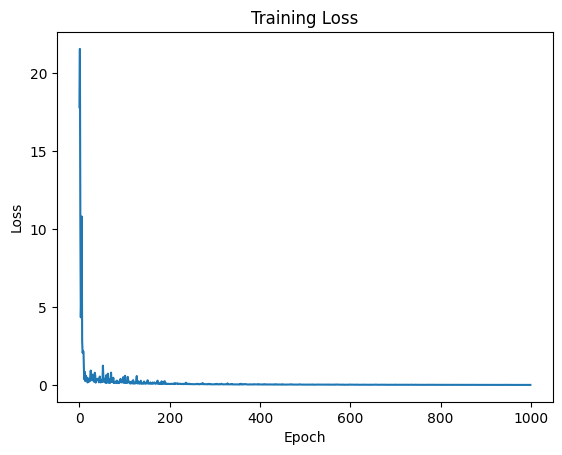

Фінальні передбачення:
tensor([[5.7505e-02],
        [9.6006e-01],
        [9.9962e-01],
        [3.4785e-11],
        [1.0000e+00],
        [5.7505e-02],
        [9.6006e-01],
        [9.9962e-01],
        [3.4785e-11],
        [1.0000e+00],
        [5.7505e-02],
        [9.6006e-01],
        [9.9962e-01],
        [3.4785e-11],
        [1.0000e+00]])

Передбачені класи (поріг 0.5):
tensor([[0.],
        [1.],
        [1.],
        [0.],
        [1.],
        [0.],
        [1.],
        [1.],
        [0.],
        [1.],
        [0.],
        [1.],
        [1.],
        [0.],
        [1.]])

Справжні мітки:
tensor([[0.],
        [1.],
        [1.],
        [0.],
        [1.],
        [0.],
        [1.],
        [1.],
        [0.],
        [1.],
        [0.],
        [1.],
        [1.],
        [0.],
        [1.]])


In [21]:
import matplotlib.pyplot as plt

def fit(num_epochs, model, loss_fn, opt, train_dl):
    losses = []
    for epoch in range(num_epochs):
        total_loss = 0
        for xb, yb in train_dl:
            pred = model(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            opt.step()
            opt.zero_grad()
            total_loss += loss.item()
        avg_loss = total_loss / len(train_dl)
        losses.append(avg_loss)
        if (epoch + 1) % 10 == 0:
            print(f'Epoch [{epoch+1}/1000], Loss: {avg_loss:.4f}')
    return losses

losses = fit(1000, model, loss_fn, opt, train_dl)

# Графік зміни loss
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

# Фінальні передбачення
preds = model(inputs_tensor)
print("Фінальні передбачення:")
print(preds.detach())
print("\nПередбачені класи (поріг 0.5):")
print((preds >= 0.5).float().detach())
print("\nСправжні мітки:")
print(targets_tensor)